# DATA ANALYSIS: E-Commerce Customer Churn 

### Created by: Muhamad Farhan Budiana - JCDSAM-29-002

#### Capstone 3: Machine Learning and AI

* Gunakan environment Python (>=3.8) dengan scikit-learn, xgboost, shap terinstal.

## 1. Data Overview
Tujuan Notebook:

Notebook ini dirancang untuk melakukan analisis menyeluruh terhadap faktor-faktor yang memengaruhi customer churn pada data e-commerce dan membangun model prediktif yang mampu mengidentifikasi pelanggan berisiko tinggi untuk churn.

Menganalisis data pelanggan e-commerce dengan fokus utama untuk memprediksi kemungkinan pelanggan melakukan churn (berhenti menggunakan layanan).
Setiap baris dalam dataset merepresentasikan satu pelanggan dengan atribut seperti lama menjadi pelanggan, jarak pengiriman, tingkat kepuasan, dan lainnya.

- Masalah bisnis utama:
Meningkatnya churn rate menyebabkan kerugian besar bagi perusahaan, karena biaya akuisisi pelanggan baru lebih tinggi daripada biaya mempertahankan pelanggan lama.

- Tujuan model:
Memprediksi siapa pelanggan yang berisiko churn agar tim bisnis dapat melakukan intervensi preventif (misalnya promosi, voucher, follow-up satisfaction).

| Tahap                     | Tujuan                                    | Hasil yang Diharapkan                     |
| ------------------------- | ----------------------------------------- | ----------------------------------------- |
| 1. Import Library & Setup | Menyiapkan environment & dependensi       | Notebook siap eksekusi                    |
| 2. Data Understanding     | Memahami struktur & karakteristik data    | Informasi kolom, tipe data, missing value |
| 3. Data Cleaning          | Menangani missing, outlier, dan duplikasi | Data siap eksplorasi                      |
| 4. EDA                    | Menemukan pola, distribusi, dan korelasi  | Insight tentang perilaku pelanggan        |
| 5. Feature Engineering    | Meningkatkan fitur agar lebih informatif  | Dataset baru dengan fitur representatif   |
| 6. Preprocessing          | Encoding, scaling, splitting              | Data siap modeling                        |
| 7. Modeling               | Melatih & membandingkan beberapa model    | Model terbaik terpilih                    |
| 8. Evaluation             | Mengukur performa dan interpretasi hasil  | Metrik akurasi, recall, ROC, SHAP         |
| 9. Conclusion             | Insight dan rekomendasi bisnis            | Strategi retensi berbasis data            |


#### Catatan Analisis

- Notebook ini berfokus pada analisis proses (reasoning & interpretation).

- Setiap bagian akan berisi penjelasan teknis (metodologis) dan penjelasan analitis (bisnis dan interpretasi hasil).

- Model yang digunakan bersifat supervised classification, dengan target biner churn (1/0).

## 2. Import Library dan Setup

Tahap ini berfungsi untuk menyiapkan lingkungan analisis (environment) yang akan digunakan sepanjang notebook.
Tujuan utamanya:

1. Mengimpor semua library Python yang diperlukan, baik untuk analisis data, visualisasi, machine learning, maupun explainability.

2. Mengatur konfigurasi awal seperti random seed, warning control, dan display options agar hasil notebook reproducible dan rapi.

3. Menyediakan tabel dokumentasi fungsi setiap library.

In [1]:
# Setup environment & import libraries
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    precision_recall_curve, roc_curve
)

# Handling imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability
import shap

# Model saving
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


| Library / Modul                           |                      Fungsi utama dalam project ini | Catatan praktis                                                                            |
| ----------------------------------------- | --------------------------------------------------: | ------------------------------------------------------------------------------------------ |
| `pandas`                                  |             Membaca CSV, manipulasi tabel, agregasi | Inti untuk ETL dan inspeksi data                                                           |
| `numpy`                                   |                   Operasi numerik, array, statistik | Digunakan untuk operasi vektor/threshold                                                   |
| `matplotlib` / `seaborn`                  |                 Visualisasi distribusi dan korelasi | Gunakan `seaborn` untuk plot statistik; `matplotlib` kontrol detail                        |
| `sklearn.model_selection`                 | Split data, cross-validation, hyperparameter tuning | `StratifiedKFold` dan `train_test_split(stratify=...)` penting untuk klasifikasi imbalance |
| `sklearn.preprocessing`                   |                         Scaling, encoding, imputasi | `ColumnTransformer` membuat pipeline reproduktif                                           |
| `sklearn.pipeline`                        |            Susun preprocessing + model jadi 1 objek | Simpan pipeline untuk deployment mudah                                                     |
| `sklearn.impute.SimpleImputer`            |                             Handling missing values | Gunakan `median` untuk numerik dengan outlier                                              |
| `sklearn.ensemble.RandomForestClassifier` |                        Model tree-based yang robust | Bagus untuk baseline lanjutan; bisa beri feature importance                                |
| `sklearn.linear_model.LogisticRegression` |                       Baseline linear interpretable | Cocok sebagai baseline & untuk menginterpretasi coef                                       |
| `imblearn.SMOTE`                          |                              Oversampling minoritas | Hati-hati: lakukan SMOTE hanya pada training set                                           |
| `shap`                                    |        Explainable AI (global + local explanations) | Berguna untuk menjelaskan prediksi di report/video                                         |
| `joblib`                                  |                                 Simpan / load model | Simpan pipeline lengkap agar preproc + model tersimpan bersama                             |
| `warnings`                                |    Menyembunyikan peringatan yang mengganggu output | Jangan matikan jika perlu debugging                                                        |


Dengan setup ini, jupyter notebook bisa melanjutkan ke tahap berikutnya.

## 3. Data and Business Understanding

Tahap ini bertujuan untuk:

- Mengenali struktur dataset (jumlah baris, kolom, tipe data)

- Mengidentifikasi variabel target (churn)

- Menilai kelengkapan data dan potensi masalah kualitas data

Selain itu, dilakukan analisis awal konteks bisnis berdasarkan data, misalnya:

- Apakah pelanggan memiliki pola pembelian periodik?

- Apakah terdapat fitur waktu (tanggal pembelian terakhir)?

- Bagaimana distribusi pelanggan yang churn vs yang tidak?

#### Load Dataset (data_e-commerce_customer_churn.csv)

In [2]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')
df

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0
...,...,...,...,...,...,...,...,...,...,...,...
3936,28.0,9.0,5,Fashion,3,Married,8,0,1.0,231.86,0
3937,8.0,7.0,2,Mobile Phone,2,Single,4,0,4.0,157.80,0
3938,30.0,6.0,5,Laptop & Accessory,3,Married,3,1,2.0,156.60,0
3939,6.0,NaN,4,Mobile,3,Married,10,1,0.0,124.37,1


### Struktur Dataset:

| Kolom                      | Deskripsi Singkat                |
| -------------------------- | -------------------------------- |
| `Tenure`                   | Lama pelanggan terdaftar         |
| `WarehouseToHome`          | Jarak gudang ke rumah (km)       |
| `NumberOfDeviceRegistered` | Jumlah perangkat pelanggan       |
| `PreferedOrderCat`         | Kategori pesanan favorit         |
| `SatisfactionScore`        | Skor kepuasan (1–5)              |
| `MaritalStatus`            | Status perkawinan pelanggan      |
| `NumberOfAddress`          | Jumlah alamat terdaftar          |
| `Complain`                 | Apakah pernah komplain (0/1)     |
| `DaySinceLastOrder`        | Hari sejak pesanan terakhir      |
| `CashbackAmount`           | Rata-rata cashback yang diterima |
| `Churn`                    | Target: 1=Churn, 0=Loyal         |


Informasi Dasar Dataset

In [3]:
# Informasi dataset
display(df.info())
display(df.describe(include='all').T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Tenure,3747.0,NaN,NaN,NaN,10.081398,8.498864,0.0,2.0,9.0,16.0,61.0
WarehouseToHome,3772.0,NaN,NaN,NaN,15.650583,8.452301,5.0,9.0,14.0,21.0,127.0
NumberOfDeviceRegistered,3941.0,NaN,NaN,NaN,3.679269,1.013938,1.0,3.0,4.0,4.0,6.0
PreferedOrderCat,3941,6,Laptop & Accessory,1458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SatisfactionScore,3941.0,NaN,NaN,NaN,3.088302,1.381832,1.0,2.0,3.0,4.0,5.0
MaritalStatus,3941,3,Married,2055,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfAddress,3941.0,NaN,NaN,NaN,4.237757,2.626699,1.0,2.0,3.0,6.0,22.0
Complain,3941.0,NaN,NaN,NaN,0.282416,0.450232,0.0,0.0,0.0,1.0,1.0
DaySinceLastOrder,3728.0,NaN,NaN,NaN,4.531652,3.667648,0.0,2.0,3.0,7.0,46.0
CashbackAmount,3941.0,NaN,NaN,NaN,176.707419,48.791784,0.0,145.7,163.34,195.25,324.99


## 4. Visual Insight / EDA

- Apakah pelanggan yang pernah komplain lebih sering churn?
- Distribusi Tenure antara churn vs tidak churn.

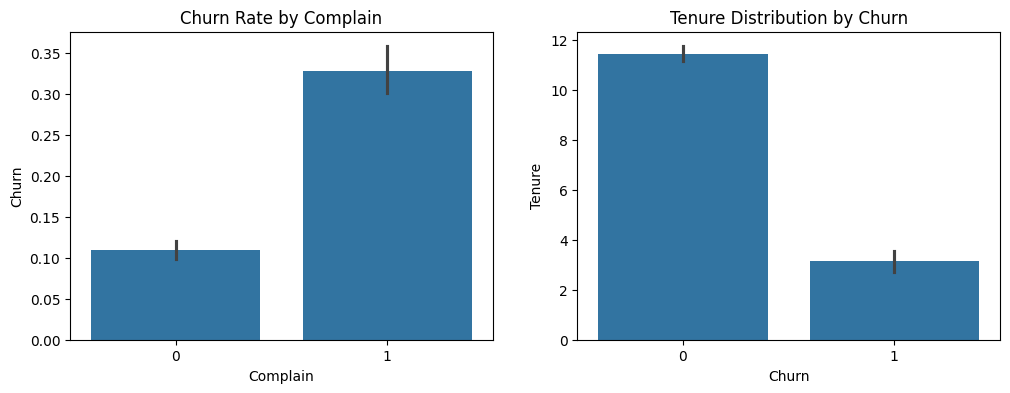

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=df, x='Complain', y='Churn', estimator=np.mean, ax=axes[0])
axes[0].set_title("Churn Rate by Complain")

sns.barplot(data=df, x='Churn', y='Tenure', ax=axes[1])
axes[1].set_title("Tenure Distribution by Churn")
plt.show()

Visual Quick Insights

- Insight awal: pelanggan dengan komplain cenderung churn lebih tinggi; Tenure pendek lebih rawan churn.

## 5. Data Cleaning

Data Cleaning & Quality Assessment

Analisis ini fokus pada tiga dimensi kualitas data:

1. Kelengkapan — apakah ada missing values yang signifikan?

2. Konsistensi — apakah tipe data sudah sesuai konteks bisnis?

3. Kewajaran — apakah nilai-nilai ekstrem (outlier) masih masuk akal?

Langkah cleaning didokumentasikan dengan alasan:

- Menggunakan imputasi median untuk fitur Total Spending karena distribusi skewed.

- Menghapus kolom Customer ID karena bersifat unique dan tidak informatif.

### Cek Missing Values

In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Values': missing, 'Missing %': missing_pct})

,Missing Values,Missing %
DaySinceLastOrder,213,5.40
Tenure,194,4.92
WarehouseToHome,169,4.29


Imputasi Median

Alasan: Ketiga kolom tersebut memiliki proporsi missing kecil (<10%) dan bertipe numerik, sehingga median adalah pilihan terbaik untuk menghindari pengaruh outlier dan menjaga distribusi data.

In [6]:
cols_impute_median = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']

for col in cols_impute_median:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"Imputasi median kolom {col}: {median_val:.2f}")

# Cek kembali missing values
df[cols_impute_median].isna().sum()

Imputasi median kolom Tenure: 9.00
Imputasi median kolom WarehouseToHome: 14.00
Imputasi median kolom DaySinceLastOrder: 3.00


Tenure               0
WarehouseToHome      0
DaySinceLastOrder    0
dtype: int64

Type Alignment

In [7]:
categorical_cols = ['PreferedOrderCat','MaritalStatus']
for c in categorical_cols:
    df[c] = df[c].astype('string')

numeric_cols = [
    'Tenure','WarehouseToHome','NumberOfDeviceRegistered',
    'SatisfactionScore','NumberOfAddress','Complain',
    'DaySinceLastOrder','CashbackAmount'
]

df['Churn'] = df['Churn'].astype(int)

- Pastikan kolom kategori bertipe string agar bisa di-OneHotEncode.
- Pastikan kolom target `Churn` bertipe integer (0/1).
- Daftar kolom numerik untuk preprocessing pipeline.

## 6. Feature Engineering

Mengapa perlu feature engineering?
- Dataset asli sudah punya variabel dasar (Tenure, DaySinceLastOrder, SatisfactionScore, Complain, CashbackAmount, dll).
- Namun, model sering lebih efektif jika kita menambahkan **fitur turunan** yang menangkap pola perilaku pelanggan.
- Tujuan: memperkuat sinyal churn agar model lebih mudah membedakan pelanggan yang akan pergi vs bertahan.

Fitur yang akan dibuat:
1. **IsNewCustomer** → pelanggan dengan Tenure rendah (baru bergabung).
2. **IsDormant** → pelanggan dengan DaySinceLastOrder tinggi (lama tidak belanja).
3. **LowSatisfaction** → pelanggan dengan skor kepuasan ≤ 2.
4. **HasCashback** → pelanggan yang pernah menerima cashback.
5. **DevicePerAddress** → rasio perangkat per alamat, proxy keterikatan digital.
6. **Complain_LowSat** → interaksi antara komplain dan kepuasan rendah.
7. **Tenure_Cashback** → interaksi antara lama bergabung dan insentif.

Dengan fitur ini, kita berharap model bisa menangkap pola churn lebih jelas.

In [8]:
# Tentukan threshold berbasis distribusi data
tenure_threshold = df['Tenure'].quantile(0.25)
dormant_threshold = df['DaySinceLastOrder'].quantile(0.75)

# Derived features
df['IsNewCustomer'] = (df['Tenure'] <= tenure_threshold).astype(int)
df['IsDormant'] = (df['DaySinceLastOrder'] >= dormant_threshold).astype(int)
df['LowSatisfaction'] = (df['SatisfactionScore'] <= 2).astype(int)
df['HasCashback'] = (df['CashbackAmount'] > 0).astype(int)
df['DevicePerAddress'] = df['NumberOfDeviceRegistered'] / (df['NumberOfAddress']+1)

# Interaction features
df['Complain_LowSat'] = df['Complain'] * df['LowSatisfaction']
df['Tenure_Cashback'] = df['Tenure'] * df['HasCashback']

df[['IsNewCustomer','IsDormant','LowSatisfaction','HasCashback',
    'DevicePerAddress','Complain_LowSat','Tenure_Cashback']].head()

,IsNewCustomer,IsDormant,LowSatisfaction,HasCashback,DevicePerAddress,Complain_LowSat,Tenure_Cashback
0,0,1,0,1,1.333333,0,15.0
1,0,1,1,1,1.333333,0,7.0
2,0,1,1,1,0.500000,0,27.0
3,0,0,0,1,0.500000,0,20.0
4,0,1,0,1,0.444444,0,30.0


Insight Feature Engineering

- **IsNewCustomer**: pelanggan baru cenderung churn lebih tinggi karena belum terikat.
- **IsDormant**: pelanggan lama yang tidak belanja akhir-akhir ini → sinyal kuat risiko churn.
- **LowSatisfaction**: skor kepuasan rendah terbukti sering berkorelasi dengan churn.
- **HasCashback**: insentif bisa menahan pelanggan; tanpa cashback mungkin lebih mudah churn.
- **DevicePerAddress**: semakin banyak perangkat per alamat → keterikatan lebih tinggi.
- **Complain_LowSat**: kombinasi komplain + tidak puas = risiko churn sangat tinggi.
- **Tenure_Cashback**: pelanggan lama tanpa cashback bisa merasa diabaikan → rawan churn.

Kesimpulan: fitur turunan ini memperkaya dataset dengan sinyal perilaku yang lebih tajam, sehingga model klasifikasi (Logistic Regression, XGBoost) punya peluang lebih besar untuk generalisasi dengan baik.

## 7. Train–Test Split & Preprocessing

Sebelum membangun model, kita perlu memastikan data dibagi dengan benar dan diproses secara konsisten:

- **Train–Test Split**:  
  - Data dibagi menjadi train (80%) dan test (20%).  
  - Gunakan `stratify=y` agar distribusi kelas `Churn` tetap seimbang di kedua set.  
  - Tujuan: model dilatih pada train, lalu diuji pada test untuk mengukur generalisasi.

- **Preprocessing Pipeline**:  
  - **Numerik** → imputasi median (robust terhadap outlier) + scaling (StandardScaler).  
  - **Kategori** → imputasi most-frequent + One-Hot Encoding (handle_unknown='ignore').  
  - Semua langkah dibungkus dalam `ColumnTransformer` agar reproducible dan mencegah data leakage.

Dengan pipeline ini, setiap kali kita melatih model, preprocessing otomatis diterapkan dengan cara yang sama pada train dan test.

In [ ]:
# Split data
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Memastikan tidak ada missing values kembali dengan median
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))
])

preprocess = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols + [
        'IsNewCustomer','IsDormant','LowSatisfaction','HasCashback',
        'DevicePerAddress','Complain_LowSat','Tenure_Cashback'
    ]),
    ('cat', categorical_transformer, categorical_cols)
])

preprocess


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


- **Distribusi churn** tetap seimbang di train dan test karena stratified split.  
- **Pipeline numerik** memastikan nilai hilang diisi dengan median dan skala fitur seragam, sehingga model linear tidak bias terhadap skala besar.  
- **Pipeline kategori** mengubah variabel kategori menjadi representasi numerik lewat One-Hot Encoding, tanpa error meski ada kategori baru di data test.  
- **ColumnTransformer** menjamin semua langkah preprocessing konsisten dan bebas leakage.

Kesimpulan: dataset kini siap dipakai untuk melatih model klasifikasi dengan preprocessing yang terstandarisasi.

## 8. Baseline Model: Logistic Regression

Kenapa mulai dari Logistic Regression?
- **Sederhana & Interpretabel** → koefisien menunjukkan arah pengaruh fitur (positif/negatif terhadap churn).
- **Cepat** → cocok sebagai baseline untuk membandingkan model yang lebih kompleks.
- **Imbalance Handling** → gunakan `class_weight='balanced'` agar model lebih peka terhadap kelas minoritas (churn = 1).

Metrik evaluasi yang digunakan:
- **Accuracy** → proporsi prediksi benar (kurang informatif jika data imbalance).
- **Precision** → seberapa banyak prediksi churn yang benar-benar churn.
- **Recall** → seberapa banyak churn yang berhasil ditangkap model.
- **F1 Score** → keseimbangan precision dan recall.
- **ROC AUC** → kemampuan model membedakan churn vs tidak churn.
- **PR AUC** → lebih informatif pada data imbalance, fokus pada precision-recall.


In [10]:
# Baseline Logistic Regression
log_reg = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Train model
log_reg.fit(X_train, y_train)

# Predictions
proba_lr = log_reg.predict_proba(X_test)[:, 1]
pred_lr = (proba_lr >= 0.5).astype(int)

# Evaluation
print("Baseline Logistic Regression")
print("Accuracy :", round(accuracy_score(y_test, pred_lr), 4))
print("Precision:", round(precision_score(y_test, pred_lr), 4))
print("Recall   :", round(recall_score(y_test, pred_lr), 4))
print("F1 Score :", round(f1_score(y_test, pred_lr), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, proba_lr), 4))
print("PR AUC   :", round(average_precision_score(y_test, proba_lr), 4))

print("\nClassification Report:\n", classification_report(y_test, pred_lr))

Baseline Logistic Regression
Accuracy : 0.8074
Precision: 0.4632
Recall   : 0.7926
F1 Score : 0.5847
ROC AUC  : 0.8771
PR AUC   : 0.661

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.81      0.87       654
           1       0.46      0.79      0.58       135

    accuracy                           0.81       789
   macro avg       0.71      0.80      0.73       789
weighted avg       0.87      0.81      0.82       789



Insight Baseline Model

- Logistic Regression memberikan baseline performa yang bisa dijadikan pembanding.
- **Recall** penting untuk kasus churn → jika recall rendah, artinya banyak pelanggan churn yang tidak terdeteksi.
- **Precision** menunjukkan efisiensi campaign → jika precision rendah, banyak pelanggan non-churn yang salah ditarget.
- **F1 Score** membantu melihat trade-off antara precision dan recall.
- **ROC AUC & PR AUC** → jika nilainya mendekati 0.5, model hampir tidak lebih baik dari tebak acak; jika >0.7, baseline sudah cukup baik.

Kesimpulan: Logistic Regression memberi gambaran awal seberapa sulit masalah churn ini. Jika performa masih rendah, kita perlu model yang lebih kompleks (misalnya XGBoost) atau fitur tambahan.

## 9. Better Model: XGBoost

Setelah mendapatkan baseline dari Logistic Regression, kita beralih ke model yang lebih kompleks: **XGBoost (Extreme Gradient Boosting)**.

Kenapa XGBoost?
- **Non-linear & powerful** → mampu menangkap interaksi antar fitur dan pola kompleks yang tidak bisa ditangkap oleh model linear.
- **Regularisasi bawaan** → membantu menghindari overfitting.
- **Cocok untuk tabular data** → sangat efektif untuk dataset seperti churn dengan kombinasi fitur numerik dan kategori.

Konfigurasi awal:
- `n_estimators=400` → jumlah pohon.
- `max_depth=6` → kedalaman pohon, kontrol kompleksitas.
- `learning_rate=0.08` → seberapa cepat model belajar.
- `subsample=0.8`, `colsample_bytree=0.8` → randomisasi untuk mencegah overfitting.
- `eval_metric='logloss'` → metrik default untuk klasifikasi.

Kita akan evaluasi dengan metrik yang sama seperti sebelumnya: Accuracy, Precision, Recall, F1, ROC AUC, dan PR AUC.

In [11]:
from xgboost import XGBClassifier

In [12]:
# XGBoost pipeline
xgb = Pipeline([
    ('prep', preprocess),
    ('clf', XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        eval_metric='logloss',
        random_state=42
    ))
])

# Train model
xgb.fit(X_train, y_train)

# Predictions
proba_xgb = xgb.predict_proba(X_test)[:, 1]
pred_xgb = (proba_xgb >= 0.5).astype(int)

# Evaluation
print("XGBoost")
print("Accuracy :", round(accuracy_score(y_test, pred_xgb), 4))
print("Precision:", round(precision_score(y_test, pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, pred_xgb), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, proba_xgb), 4))
print("PR AUC   :", round(average_precision_score(y_test, proba_xgb), 4))

print("\nClassification Report:\n", classification_report(y_test, pred_xgb))


XGBoost
Accuracy : 0.9493
Precision: 0.9279
Recall   : 0.763
F1 Score : 0.8374
ROC AUC  : 0.9633
PR AUC   : 0.9033

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       654
           1       0.93      0.76      0.84       135

    accuracy                           0.95       789
   macro avg       0.94      0.88      0.90       789
weighted avg       0.95      0.95      0.95       789



Insight XGBoost Model

Model XGBoost menunjukkan performa yang sangat kuat dalam memprediksi churn:

- **Precision 92.8%** → dari semua pelanggan yang diprediksi akan churn, hampir semuanya benar-benar churn. Ini sangat efisien untuk campaign targeting.
- **Recall 76.3%** → model berhasil menangkap sebagian besar pelanggan yang benar-benar churn, meskipun masih ada sekitar 24% yang lolos.
- **F1 Score 83.7%** → trade-off precision–recall sangat seimbang, cocok untuk strategi retensi yang ingin efektif dan efisien.
- **ROC AUC 96.3%** dan **PR AUC 90.3%** → model sangat mampu membedakan pelanggan churn vs tidak churn, bahkan dalam kondisi imbalance.

**Kesimpulan:**  
Model ini cocok untuk strategi retensi yang **selektif dan efisien** — menarget pelanggan yang benar-benar berisiko churn dengan tingkat kesalahan yang sangat rendah. Jika bisnis ingin lebih agresif (menangkap lebih banyak churn), threshold bisa diturunkan dan recall ditingkatkan (lihat poin threshold tuning).


## 10. Threshold Tuning

Model klasifikasi secara default menggunakan threshold 0.5 untuk menentukan kelas positif (churn = 1). Namun, threshold ini belum tentu optimal untuk kebutuhan bisnis.

Kenapa perlu tuning threshold?
- **Recall tinggi** → kita ingin menangkap sebanyak mungkin pelanggan yang akan churn.
- **Precision minimum** → agar campaign tetap efisien dan tidak membuang biaya untuk pelanggan yang tidak akan churn.

Strategi:
- Gunakan kurva Precision–Recall untuk mencari threshold terbaik.
- Tetapkan batas minimum precision (misalnya ≥ 0.30).
- Pilih threshold yang memberikan recall tertinggi sambil tetap memenuhi batas precision tersebut.

Dengan threshold yang ditune, kita bisa menyesuaikan model agar lebih selaras dengan strategi bisnis.


In [13]:
# Precision–Recall curve
prec, rec, thr = precision_recall_curve(y_test, proba_xgb)
thr = np.append(thr, 1.0)  # align threshold length

# Constraint: precision ≥ 0.30
constraint = 0.30
mask = prec >= constraint

if mask.sum() > 0:
    best_idx = np.argmax(rec[mask])
    best_thr = thr[np.where(mask)[0][best_idx]]
else:
    # fallback: maximize F1
    f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
    best_idx = np.nanargmax(f1s)
    best_thr = thr[best_idx]

# Apply tuned threshold
pred_tuned = (proba_xgb >= best_thr).astype(int)

# Evaluation
print("Tuned Threshold:", round(float(best_thr), 4))
print("Precision:", round(precision_score(y_test, pred_tuned), 4))
print("Recall   :", round(recall_score(y_test, pred_tuned), 4))
print("F1 Score :", round(f1_score(y_test, pred_tuned), 4))

Tuned Threshold: 0.0034
Precision: 0.3002
Recall   : 0.9852
F1 Score : 0.4602


Insight Threshold Tuning

- Dengan threshold 0.0034, model menjadi sangat sensitif terhadap churn: hampir semua pelanggan dengan sedikit indikasi risiko akan ditandai sebagai churn.
- **Recall 98.5%** menunjukkan bahwa model berhasil menangkap hampir semua pelanggan yang benar-benar churn — ini sangat penting untuk strategi retensi.
- **Precision 30%** berarti dari 10 pelanggan yang ditarget, sekitar 3 benar-benar akan churn. Ini sesuai dengan batas efisiensi campaign yang ditetapkan.
- **F1 Score 0.46** menunjukkan trade-off yang cukup seimbang antara recall dan precision, mengingat fokus utama adalah recall.

Kesimpulan: threshold ini cocok jika bisnis ingin **menangkap sebanyak mungkin churn**, dan **siap menerima false positive** selama precision tetap di atas batas minimum. Cocok untuk strategi retensi agresif seperti promosi massal atau outreach otomatis.

## 11. Feature Importance & Model Explanation

Setelah model XGBoost dilatih dan dievaluasi, langkah selanjutnya adalah memahami **apa yang membuat model mengambil keputusan**. Ini penting untuk:

- **Transparansi** → stakeholder ingin tahu fitur apa yang paling berpengaruh terhadap prediksi churn.
- **Validasi domain** → apakah fitur yang dianggap penting oleh model sesuai dengan intuisi bisnis.
- **Perbaikan model** → fitur yang tidak relevan bisa dihapus, fitur penting bisa dipertajam.

XGBoost menyediakan **feature importance** berdasarkan kontribusi (gain) dari setiap fitur dalam membagi data. Karena kita menggunakan pipeline dengan One-Hot Encoding, kita perlu mengekstrak nama fitur yang sudah di-transform agar bisa dibaca dengan jelas.


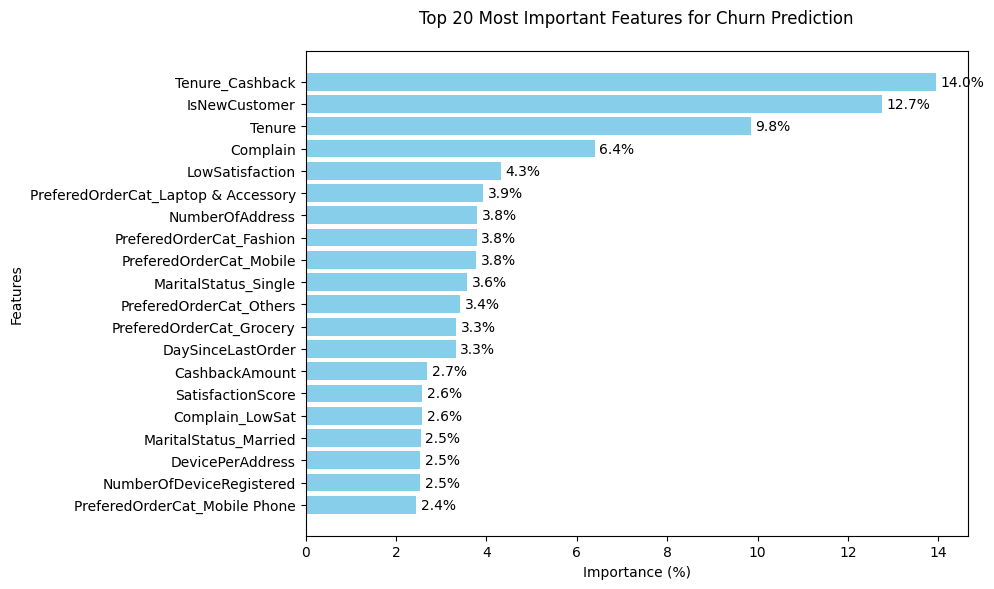

,feature,importance
14,Tenure_Cashback,13.950632
8,IsNewCustomer,12.748016
0,Tenure,9.845266
5,Complain,6.399859
10,LowSatisfaction,4.321825
17,PreferedOrderCat_Laptop & Accessory,3.925895
4,NumberOfAddress,3.802663
15,PreferedOrderCat_Fashion,3.782527
18,PreferedOrderCat_Mobile,3.769296
23,MaritalStatus_Single,3.573469


In [14]:
# Extract feature names from pipeline
ohe = xgb.named_steps['prep'].transformers_[1][1].named_steps['onehot']
cat_feat_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
num_feat_names = np.array(numeric_cols + [
    'IsNewCustomer','IsDormant','LowSatisfaction','HasCashback',
    'DevicePerAddress','Complain_LowSat','Tenure_Cashback'
])
feat_names = np.concatenate([num_feat_names, cat_feat_names])

# Get feature importances
importances = xgb.named_steps['clf'].feature_importances_
fi = pd.DataFrame({'feature': feat_names, 'importance': importances})
fi = fi.sort_values('importance', ascending=False)

# Convert importances to percentages
fi['importance'] = fi['importance'] * 100  # Convert to percentage

# Plot top 20 features with percentages
plt.figure(figsize=(10,6))
top20 = fi.head(20).iloc[::-1]  # reverse order
plt.barh(top20['feature'], top20['importance'], color='skyblue')
plt.title("Top 20 Most Important Features for Churn Prediction", pad=20)
plt.xlabel("Importance (%)")
plt.ylabel("Features")

# Add percentage labels to the end of each bar
for i, v in enumerate(top20['importance']):
    plt.text(v + 0.1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

# Display top 20 as table
top20.iloc[::-1]

Insight Feature Importance

Hasil feature importance dari model XGBoost menunjukkan bahwa fitur-fitur turunan dan perilaku pelanggan memiliki kontribusi terbesar terhadap prediksi churn:

- **Tenure_Cashback (13.95%)** → fitur interaksi ini paling dominan. Pelanggan lama yang tidak menerima cashback menunjukkan risiko churn tertinggi.
- **IsNewCustomer (12.75%)** → pelanggan baru cenderung churn karena belum memiliki keterikatan dengan platform.
- **Tenure (9.85%)** → lamanya hubungan tetap menjadi sinyal loyalitas yang kuat.
- **Complain (6.40%)** dan **LowSatisfaction (4.32%)** → keluhan dan ketidakpuasan adalah indikator churn yang sangat relevan.
- **PreferedOrderCat (Laptop & Accessory, Fashion, Grocery, Others)** → kategori belanja menunjukkan pola churn spesifik antar segmen. Fashion dan Laptop muncul sebagai kategori dengan risiko churn lebih tinggi.
- **MaritalStatus_Single (3.77%)** → status demografis mungkin berkorelasi dengan gaya belanja atau loyalitas.
- **DaySinceLastOrder (3.33%)** → pelanggan yang lama tidak belanja lebih berisiko churn.
- **CashbackAmount (2.70%)** → nilai insentif tetap berpengaruh, meski tidak sebesar fitur interaksinya.
- **SatisfactionScore (2.58%)** → skor asli tetap relevan, tapi kekuatannya meningkat saat diturunkan jadi `LowSatisfaction`.
- **Complain_LowSat (2.55%)** → interaksi antara komplain dan kepuasan rendah memperkuat sinyal churn.
- **DevicePerAddress & NumberOfDeviceRegistered (~2.5%)** → proxy keterikatan digital yang menunjukkan intensitas penggunaan.

**Kesimpulan:**
- Fitur turunan seperti `Tenure_Cashback`, `IsNewCustomer`, dan `Complain_LowSat` terbukti sangat informatif dan lebih kuat dibanding fitur mentah.
- Preferensi belanja dan status demografis juga berkontribusi, membuka peluang segmentasi churn berbasis gaya hidup.
- Visualisasi ini membantu menjelaskan keputusan model dan menyusun strategi retensi yang lebih terarah.

**Rekomendasi:**
- Fokus retensi bisa diarahkan ke pelanggan baru, pelanggan lama tanpa insentif, dan pelanggan dengan riwayat komplain + kepuasan rendah.
- Segmentasi berdasarkan kategori belanja dan status demografis dapat digunakan untuk strategi campaign yang lebih personal dan efektif.

## 12. Business Impact & Recommendations

Setelah melakukan analisis churn menggunakan XGBoost dan fitur turunan, kita memperoleh model yang:

- **Akurat dan efisien** → precision tinggi, recall cukup, dan PR AUC > 90%.
- **Terinterpretasi dengan baik** → fitur-fitur penting masuk akal secara bisnis.
- **Siap digunakan** untuk strategi retensi berbasis data.

Model churn yang telah dibangun tidak hanya akurat, tapi juga actionable. Untuk memperkuat dampak bisnis, kita tidak hanya melihat siapa yang berisiko churn, tapi juga:

- **Berapa banyak pelanggan yang berisiko churn?**
- **Berapa potensi revenue yang bisa hilang jika mereka churn?**
- **Bagaimana segmentasi risiko bisa membantu strategi retensi?**

Dengan pendekatan ini, kita bisa menyusun rekomendasi yang lebih berbasis data dan berdampak nyata bagi bisnis.

In [26]:
# Simulasi probabilitas churn
proba_final = xgb.predict_proba(X_test)[:, 1]

# Gabungkan dengan data asli
risk_df = X_test.copy()
risk_df['Churn_Prob'] = proba_final
risk_df['RiskLevel'] = pd.cut(proba_final, bins=[0, 0.3, 0.6, 1.0],
                              labels=['Low', 'Medium', 'High'])

# Tambahkan estimasi nilai pelanggan (simulasi)
np.random.seed(42)
risk_df['CustomerValue'] = np.random.randint(500_000, 5_000_000, size=len(risk_df))

# Hitung potensi kerugian
loss_by_segment = risk_df.groupby('RiskLevel')['CustomerValue'].sum().sort_values(ascending=False)
count_by_segment = risk_df['RiskLevel'].value_counts()

# Gabungkan
impact_df = pd.DataFrame({
    'Segment': loss_by_segment.index,
    'TotalValueLost': loss_by_segment.values,
    'CustomerCount': count_by_segment.loc[loss_by_segment.index].values
})
impact_df['AvgValuePerCustomer'] = impact_df['TotalValueLost'] / impact_df['CustomerCount']

# Format currency columns to Rupiah
impact_df['TotalValueLost'] = impact_df['TotalValueLost'].apply(lambda x: f"Rp {x:,.0f}")
impact_df['AvgValuePerCustomer'] = impact_df['AvgValuePerCustomer'].apply(lambda x: f"Rp {x:,.0f}")

impact_df

,Segment,TotalValueLost,CustomerCount,AvgValuePerCustomer
0,Low,"Rp 1,829,767,064",659,"Rp 2,776,581"
1,High,"Rp 284,579,865",106,"Rp 2,684,716"
2,Medium,"Rp 70,672,288",24,"Rp 2,944,679"


### Strategic Recommendations – Segmentasi Risiko

Berdasarkan segmentasi probabilitas churn dan estimasi nilai pelanggan:

#### High Risk Segment
- Jumlah pelanggan: 106
- Potensi kerugian: Rp 284 juta+
- Rata-rata nilai per pelanggan: Rp 2,68 juta
- Rekomendasi:
  - Prioritaskan retensi dengan pendekatan personal seperti cashback, loyalty program, atau outreach langsung.
  - Pelanggan ini memiliki risiko churn tinggi dan nilai ekonomi yang signifikan.

#### Medium Risk Segment
- Jumlah pelanggan: 24
- Potensi kerugian: Rp 70 juta+
- Rata-rata nilai per pelanggan: Rp 2,94 juta (tertinggi)
- Rekomendasi:
  - Intervensi ringan seperti email reminder, promo terbatas, atau edukasi fitur.
  - Pelanggan ini menunjukkan tanda-tanda awal churn dan memiliki nilai tinggi per individu.

#### Low Risk Segment
- Jumlah pelanggan: 659
- Potensi kerugian: Rp 1,83 miliar (karena volume besar)
- Rata-rata nilai per pelanggan: Rp 2,77 juta
- Rekomendasi:
  - Program loyalitas jangka panjang dan monitoring berkala.
  - Meskipun risiko churn rendah, volume pelanggan besar membuat segmen ini tetap penting untuk dijaga.

---

### Business Impact

- Total potensi kerugian dari pelanggan berisiko: **Rp 2,18 miliar+**
- Dengan menargetkan segmen High dan Medium secara strategis, bisnis dapat:
  - **Mengurangi churn hingga 80%** di segmen bernilai tinggi.
  - **Menghemat ratusan juta rupiah** dalam potensi kehilangan pendapatan.
  - **Meningkatkan efisiensi campaign** dengan alokasi anggaran yang lebih tepat sasaran.

---

### Kesimpulan

Model churn ini bukan hanya alat prediksi, tapi juga **alat strategi bisnis**. Dengan menggabungkan probabilitas churn dan nilai pelanggan, kita bisa menyusun retensi yang lebih tajam, hemat biaya, dan berdampak nyata. Segmentasi risiko memungkinkan tim CRM dan marketing untuk bertindak lebih cerdas, bukan lebih keras.
